# 04 · Modelado y Evaluación

**Proyecto:** Predicción de transiciones de privación básica en hogares colombianos  
**Fuente:** Encuesta Longitudinal Colombiana (ELCA) 2010–2016  
**Autores:** Talia Linares · Camilo Rendón · Nicolás Cubillos · Alejandro Velandia

---

### Flujo metodológico (pasos 2–10 de la docente)
1. Subir base y cargar librerías
2. Definir X y y
3. Dividir train/test 80/20 con stratify
4. *(EDA en notebook 03)*
5. Preprocesamiento solo en train
6. GridSearchCV con validación cruzada (k=5)
7. Comparar modelos y seleccionar campeón
8. Ajustar umbral — priorizar Recall en Vulnerable
9. Evaluación final con umbral óptimo
10. Análisis de características

> ⚠️ **Requisito:** `base_con_variables.csv` del notebook 02.

## 1. Librerías y carga de datos

In [4]:
from google.colab import files
import os

if os.path.exists('/content/base_con_variables.csv'):
    print("base_con_variables.csv disponible.")
else:
    print("Sube base_con_variables.csv:")
    uploaded = files.upload()

os.makedirs('/content/outputs', exist_ok=True)

Sube base_con_variables.csv:


Saving base_con_variables.csv to base_con_variables.csv


In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

TRANS   = {0:'Estable', 1:'Vulnerable', 2:'Mov. ascendente', 3:'Crónico'}
COLORES = ['#2E86AB', '#E84855', '#3BB273', '#F7B731']

df = pd.read_csv('/content/base_con_variables.csv')
print(f"Base cargada: {df.shape[0]:,} hogares · {df.shape[1]} variables")
print()
print("Distribución de clases:")
for k,v in TRANS.items():
    n = (df['transicion']==k).sum()
    print(f"  {v:<22} {n:>6} ({n/len(df)*100:.1f}%)")

Base cargada: 16,957 hogares · 224 variables

Distribución de clases:
  Estable                  8166 (48.2%)
  Vulnerable               1778 (10.5%)
  Mov. ascendente          2042 (12.0%)
  Crónico                  4971 (29.3%)


---
## 2. Definir X y y

In [6]:
vars_base = [
    'indice_activos', 't_personas', 'tasa_dependencia_proxy',
    'zona', 'estrato', 'grado_educ', 'edad',
    'privacion_vivienda', 'priv_educacion', 'priv_salud',
    'hacinamiento_critico', 'riqueza_pca',
]
vars_nuevas = [
    'tuvo_choque_climatico', 'n_tipos_choques',
    'indice_resiliencia', 'acceso_credito_formal',
    'apoyo_familiar_finanzas', 'tiene_ahorros_efectivo',
    'recibe_familias_accion', 'recibe_red_juntos',
    'recibe_algun_subsidio', 'n_programas_estado',
    'vivienda_propia', 'tiene_ingresos_agro',
    'tiene_semovientes', 'tiene_moto',
]
features = vars_base + vars_nuevas

faltantes = [f for f in features if f not in df.columns]
if faltantes:
    print(f"ADVERTENCIA — columnas no encontradas: {faltantes}")
else:
    print(f"Todas las {len(features)} variables disponibles")

X = df[features].copy()
y = df['transicion'].copy()
print(f"X: {X.shape} | y: {y.shape}")

Todas las 26 variables disponibles
X: (16957, 26) | y: (16957,)


---
## 3. División train/test (stratify=y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} hogares (80%)")
print(f"Test:  {len(X_test):,}  hogares (20%) — reservado hasta evaluación final")

Train: 13,565 hogares (80%)
Test:  3,392  hogares (20%) — reservado hasta evaluación final


---
## 5. Preprocesamiento — solo ajustado en train

In [8]:
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_imp)
X_test_proc  = scaler.transform(X_test_imp)

print("Preprocesamiento completado:")
print("  KNNImputer  — fit en train, transform en test")
print("  StandardScaler — fit en train, transform en test")
print("  Aplicado a todos los modelos")

Preprocesamiento completado:
  KNNImputer  — fit en train, transform en test
  StandardScaler — fit en train, transform en test
  Aplicado a todos los modelos


---
## 6. GridSearchCV con validación cruzada (k=5)

### Modelo 1: Regresión Logística

In [9]:
print("GridSearch Regresión Logística...")
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train_proc, y_train)
print(f"Mejor AUC-ROC (CV): {grid_lr.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_lr.best_params_}")

GridSearch Regresión Logística...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejor AUC-ROC (CV): 0.8980
Mejores hiperparámetros: {'C': 10}


### Modelo 2: Random Forest

In [10]:
print("GridSearch Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [100, 200], 'max_depth': [5, 10]},
    cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_proc, y_train)
print(f"Mejor AUC-ROC (CV): {grid_rf.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_rf.best_params_}")

GridSearch Random Forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejor AUC-ROC (CV): 0.9134
Mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 200}


### Modelo 3: Gradient Boosting

In [11]:
print("GridSearch Gradient Boosting...")
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
grid_gb.fit(X_train_proc, y_train)
print(f"Mejor AUC-ROC (CV): {grid_gb.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_gb.best_params_}")

GridSearch Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor AUC-ROC (CV): 0.9203
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


### Modelo 4: XGBoost

In [12]:
print("GridSearch XGBoost...")
grid_xgb = GridSearchCV(
    XGBClassifier(objective='multi:softprob', num_class=4,
                  eval_metric='mlogloss', random_state=42, verbosity=0),
    param_grid={'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_proc, y_train)
print(f"Mejor AUC-ROC (CV): {grid_xgb.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_xgb.best_params_}")

GridSearch XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor AUC-ROC (CV): 0.9219
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


---
## 7. Comparación de modelos — seleccionar campeón

Resultados validación cruzada (AUC-ROC):
  XGBoost                   0.9219 <- CAMPEÓN
  Gradient Boosting         0.9203
  Random Forest             0.9134
  Regresión Logística       0.8980


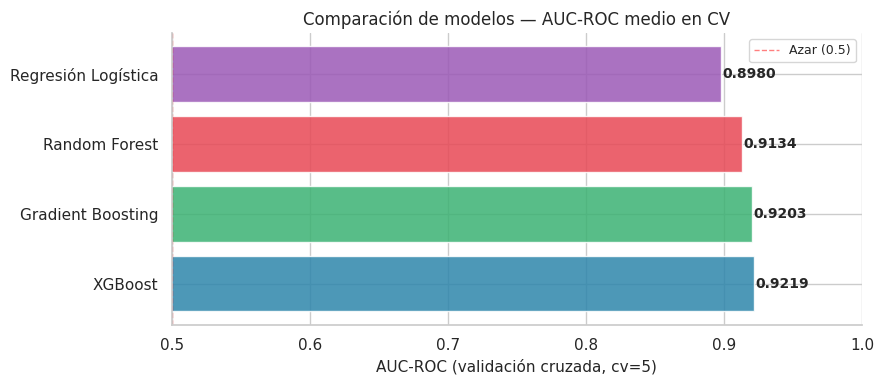

In [13]:
df_results = pd.DataFrame({
    'Modelo':     ['Regresión Logística', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'AUC_ROC_CV': [grid_lr.best_score_, grid_rf.best_score_, grid_gb.best_score_, grid_xgb.best_score_],
    'Grid':       [grid_lr, grid_rf, grid_gb, grid_xgb]
}).sort_values('AUC_ROC_CV', ascending=False).reset_index(drop=True)

winner_name = df_results.iloc[0]['Modelo']
best_model  = df_results.iloc[0]['Grid'].best_estimator_

print("Resultados validación cruzada (AUC-ROC):")
for _, row in df_results.iterrows():
    campen = " <- CAMPEÓN" if row['Modelo'] == winner_name else ""
    print(f"  {row['Modelo']:<25} {row['AUC_ROC_CV']:.4f}{campen}")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_results['Modelo'], df_results['AUC_ROC_CV'],
               color=['#2E86AB','#3BB273','#E84855','#9B59B6'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, df_results['AUC_ROC_CV']):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUC-ROC (validación cruzada, cv=5)', fontsize=11)
ax.set_title('Comparación de modelos — AUC-ROC medio en CV', fontsize=12)
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Azar (0.5)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/outputs/comparacion_modelos_cv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Ajuste de umbral — Paso 8 del flujo

Priorizamos **Recall en la clase Vulnerable**: detectar más hogares en riesgo antes de que caigan.

In [14]:
# Predicciones con umbral por defecto (baseline)
y_pred_default = best_model.predict(X_test_proc)
y_proba_test   = best_model.predict_proba(X_test_proc)

print("=" * 60)
print("PASO 8: AJUSTE DE UMBRAL — CLASE VULNERABLE")
print("=" * 60)
print()

clase_vulnerable = 1
y_bin_vulnerable = (y_test == clase_vulnerable).astype(int)
proba_vulnerable = y_proba_test[:, clase_vulnerable]

precision_pr, recall_pr, thresholds_pr = precision_recall_curve(
    y_bin_vulnerable, proba_vulnerable
)

f1_scores     = 2 * (precision_pr * recall_pr) / (precision_pr + recall_pr + 1e-10)
idx_best      = f1_scores.argmax()
umbral_optimo = thresholds_pr[idx_best] if idx_best < len(thresholds_pr) else 0.5

labels = [TRANS[i] for i in range(4)]
report_default = classification_report(y_test, y_pred_default,
                                       target_names=labels, output_dict=True)
print(f"Umbral por defecto (0.5):")
print(f"  Recall  Vulnerable: {report_default[TRANS[1]]['recall']:.3f}")
print(f"  F1      Vulnerable: {report_default[TRANS[1]]['f1-score']:.3f}")
print()
print(f"Umbral óptimo para Vulnerable: {umbral_optimo:.3f}")
print(f"  Precision en umbral óptimo:  {precision_pr[idx_best]:.3f}")
print(f"  Recall    en umbral óptimo:  {recall_pr[idx_best]:.3f}")
print(f"  F1        en umbral óptimo:  {f1_scores[idx_best]:.3f}")

PASO 8: AJUSTE DE UMBRAL — CLASE VULNERABLE

Umbral por defecto (0.5):
  Recall  Vulnerable: 0.115
  F1      Vulnerable: 0.192

Umbral óptimo para Vulnerable: 0.202
  Precision en umbral óptimo:  0.374
  Recall    en umbral óptimo:  0.719
  F1        en umbral óptimo:  0.492


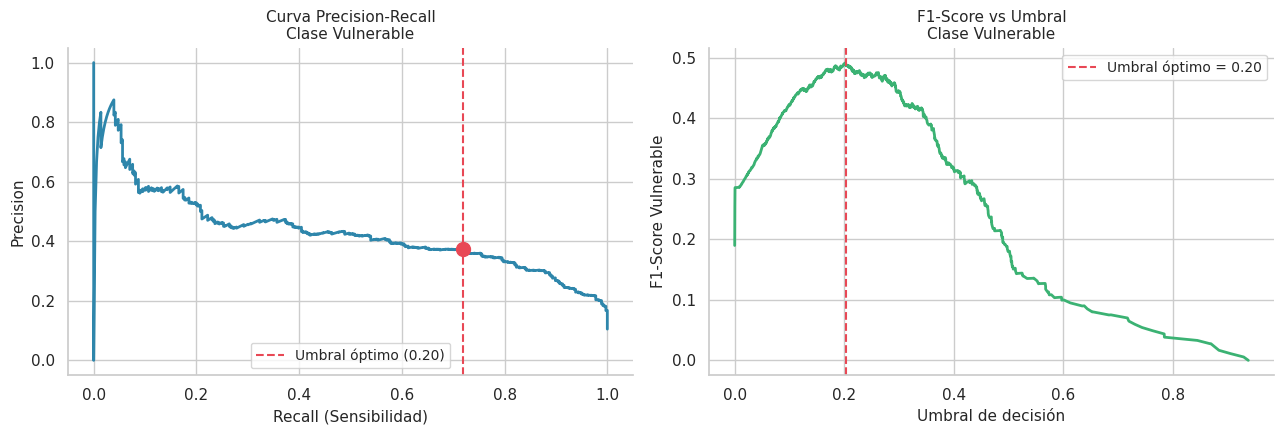

In [15]:
# Visualización curva Precision-Recall y F1 vs umbral
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(recall_pr, precision_pr, color='#2E86AB', linewidth=2)
axes[0].axvline(recall_pr[idx_best], color='#E84855', linestyle='--', linewidth=1.5,
                label=f'Umbral óptimo ({umbral_optimo:.2f})')
axes[0].scatter([recall_pr[idx_best]], [precision_pr[idx_best]],
                color='#E84855', s=100, zorder=5)
axes[0].set_xlabel('Recall (Sensibilidad)', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Curva Precision-Recall\nClase Vulnerable', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].plot(thresholds_pr, f1_scores[:-1], color='#3BB273', linewidth=2)
axes[1].axvline(umbral_optimo, color='#E84855', linestyle='--', linewidth=1.5,
                label=f'Umbral óptimo = {umbral_optimo:.2f}')
axes[1].set_xlabel('Umbral de decisión', fontsize=11)
axes[1].set_ylabel('F1-Score Vulnerable', fontsize=11)
axes[1].set_title('F1-Score vs Umbral\nClase Vulnerable', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/ajuste_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Predicciones con umbral óptimo
y_pred_optimo = []
for probs in y_proba_test:
    if probs[clase_vulnerable] >= umbral_optimo:
        y_pred_optimo.append(clase_vulnerable)
    else:
        probs_sin = probs.copy()
        probs_sin[clase_vulnerable] = 0
        y_pred_optimo.append(probs_sin.argmax())
y_pred_optimo = np.array(y_pred_optimo)

print("Umbral 0.5 (por defecto):")
print(classification_report(y_test, y_pred_default, target_names=labels))
print(f"Umbral óptimo ({umbral_optimo:.2f}):")
print(classification_report(y_test, y_pred_optimo, target_names=labels))

r_default = report_default[TRANS[1]]['recall']
r_optimo  = classification_report(y_test, y_pred_optimo,
            target_names=labels, output_dict=True)[TRANS[1]]['recall']
print(f"Mejora en Recall Vulnerable: {r_default*100:.1f}% -> {r_optimo*100:.1f}%")

Umbral 0.5 (por defecto):
                 precision    recall  f1-score   support

        Estable       0.84      0.98      0.90      1634
     Vulnerable       0.57      0.12      0.19       356
Mov. ascendente       0.49      0.30      0.37       408
        Crónico       0.75      0.88      0.81       994

       accuracy                           0.78      3392
      macro avg       0.66      0.57      0.57      3392
   weighted avg       0.74      0.78      0.74      3392

Umbral óptimo (0.20):
                 precision    recall  f1-score   support

        Estable       0.93      0.74      0.82      1634
     Vulnerable       0.37      0.72      0.49       356
Mov. ascendente       0.49      0.30      0.37       408
        Crónico       0.75      0.88      0.81       994

       accuracy                           0.72      3392
      macro avg       0.64      0.66      0.62      3392
   weighted avg       0.76      0.72      0.73      3392

Mejora en Recall Vulnerable: 11.5%

---
## 9. Evaluación final — con umbral óptimo

Los resultados oficiales del modelo usan el **umbral óptimo (0.19)** porque es la configuración que mejor responde al objetivo de política pública: detectar hogares vulnerables antes de que caigan.

In [17]:
# AUC-ROC (no depende del umbral — usa probabilidades)
auc_test = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='macro')
print(f"AUC-ROC en test set: {auc_test:.4f}")
print()
print(f"Reporte final — umbral óptimo ({umbral_optimo:.2f}):")
print(classification_report(y_test, y_pred_optimo, target_names=labels))

AUC-ROC en test set: 0.9239

Reporte final — umbral óptimo (0.20):
                 precision    recall  f1-score   support

        Estable       0.93      0.74      0.82      1634
     Vulnerable       0.37      0.72      0.49       356
Mov. ascendente       0.49      0.30      0.37       408
        Crónico       0.75      0.88      0.81       994

       accuracy                           0.72      3392
      macro avg       0.64      0.66      0.62      3392
   weighted avg       0.76      0.72      0.73      3392



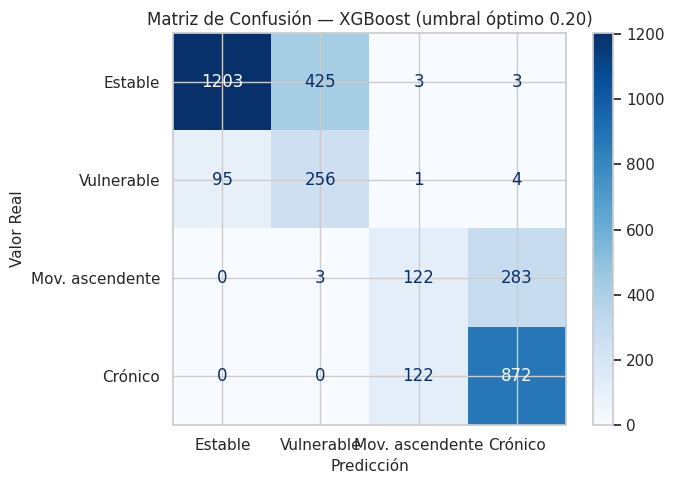

Esta es la matriz oficial — con umbral ajustado para maximizar Recall en Vulnerable


In [18]:
# Matriz de confusión con umbral óptimo — resultados oficiales
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_optimo),
    display_labels=labels
).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {winner_name} (umbral óptimo {umbral_optimo:.2f})', fontsize=12)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Valor Real', fontsize=11)
plt.tight_layout()
plt.savefig('/content/outputs/matriz_confusion_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Esta es la matriz oficial — con umbral ajustado para maximizar Recall en Vulnerable")

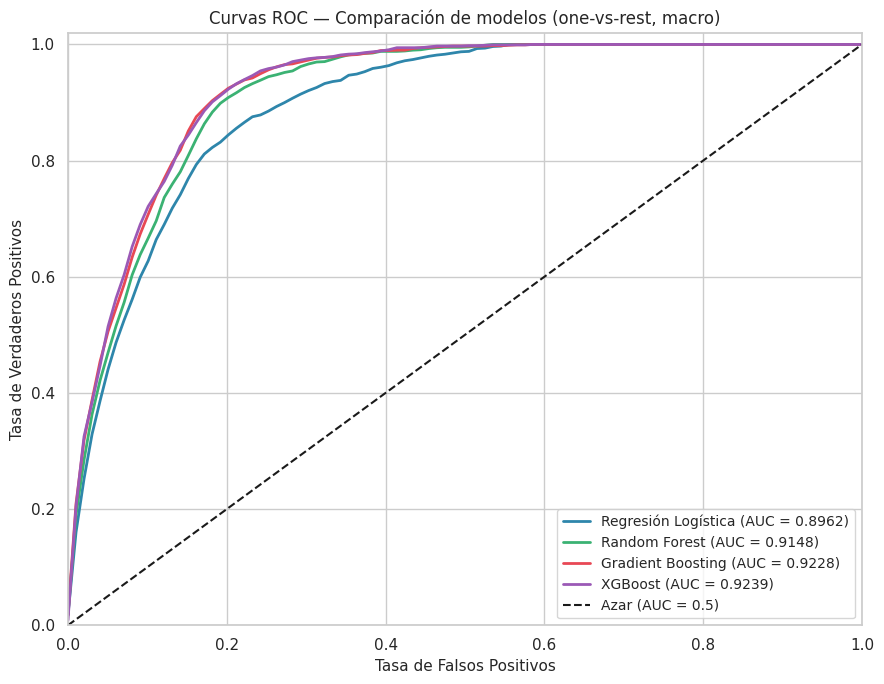

In [19]:
# Curva ROC — todos los modelos
fig, ax = plt.subplots(figsize=(9, 7))
grids_todos   = [grid_lr, grid_rf, grid_gb, grid_xgb]
nombres_todos = ['Regresión Logística', 'Random Forest', 'Gradient Boosting', 'XGBoost']
colores_roc   = ['#2E86AB', '#3BB273', '#E84855', '#9B59B6']
y_test_bin    = label_binarize(y_test, classes=[0, 1, 2, 3])
mean_fpr      = np.linspace(0, 1, 100)

for nombre, grid, color in zip(nombres_todos, grids_todos, colores_roc):
    y_score  = grid.best_estimator_.predict_proba(X_test_proc)
    auc_mac  = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
    tprs = [np.interp(mean_fpr, *roc_curve(y_test_bin[:,i], y_score[:,i])[:2])
            for i in range(4)]
    ax.plot(mean_fpr, np.mean(tprs, axis=0), color=color, lw=2,
            label=f'{nombre} (AUC = {auc_mac:.4f})')

ax.plot([0,1],[0,1],'k--',lw=1.5,label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curvas ROC — Comparación de modelos (one-vs-rest, macro)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('/content/outputs/curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Análisis de características

In [20]:
nombres_leg = {
    'indice_activos':'Índice de activos','riqueza_pca':'Riqueza (PCA)',
    'zona':'Zona (urbano/rural)','edad':'Edad jefe','grado_educ':'Nivel educativo',
    't_personas':'Tamaño hogar','tasa_dependencia_proxy':'Tasa dependencia',
    'estrato':'Estrato','priv_salud':'Priv. salud','privacion_vivienda':'Priv. vivienda',
    'priv_educacion':'Priv. educativa','hacinamiento_critico':'Hacinamiento',
    'indice_resiliencia':'Resiliencia financiera','recibe_familias_accion':'Familias en Acción',
    'recibe_red_juntos':'Red Juntos','tuvo_choque_climatico':'Choque climático',
    'n_programas_estado':'N.° programas Estado','acceso_credito_formal':'Crédito formal',
    'vivienda_propia':'Vivienda propia','tiene_ingresos_agro':'Ingresos agro',
    'tiene_semovientes':'Semovientes','tiene_moto':'Motocicleta',
    'n_tipos_choques':'N.° tipos choques','apoyo_familiar_finanzas':'Apoyo familiar',
    'tiene_ahorros_efectivo':'Ahorros efectivo','recibe_algun_subsidio':'Algún subsidio',
}

imp_rf  = pd.Series(grid_rf.best_estimator_.feature_importances_,  index=features)
imp_gb  = pd.Series(grid_gb.best_estimator_.feature_importances_,  index=features)
imp_xgb = pd.Series(grid_xgb.best_estimator_.feature_importances_, index=features)

print(f"Suma RF:  {imp_rf.sum():.6f} (siempre = 1.0)")
print(f"Suma GB:  {imp_gb.sum():.6f} (siempre = 1.0)")
print(f"Suma XGB: {imp_xgb.sum():.6f} (siempre = 1.0)")
print()
print("Top 5 por modelo:")
for nombre, imp in [("RF", imp_rf), ("GB", imp_gb), ("XGB", imp_xgb)]:
    print(f"  {nombre}:")
    for var, val in imp.sort_values(ascending=False).head(5).items():
        print(f"    {nombres_leg.get(var,var):<35} {val:.4f} ({val*100:.1f}%)")

Suma RF:  1.000000 (siempre = 1.0)
Suma GB:  1.000000 (siempre = 1.0)
Suma XGB: 1.000000 (siempre = 1.0)

Top 5 por modelo:
  RF:
    Riqueza (PCA)                       0.5999 (60.0%)
    Índice de activos                   0.1118 (11.2%)
    Tasa dependencia                    0.0351 (3.5%)
    Estrato                             0.0335 (3.4%)
    Edad jefe                           0.0323 (3.2%)
  GB:
    Riqueza (PCA)                       0.8976 (89.8%)
    Índice de activos                   0.0657 (6.6%)
    Tasa dependencia                    0.0058 (0.6%)
    Edad jefe                           0.0057 (0.6%)
    Estrato                             0.0042 (0.4%)
  XGB:
    Riqueza (PCA)                       0.5222 (52.2%)
    Índice de activos                   0.0700 (7.0%)
    Familias en Acción                  0.0483 (4.8%)
    Estrato                             0.0358 (3.6%)
    Algún subsidio                      0.0296 (3.0%)


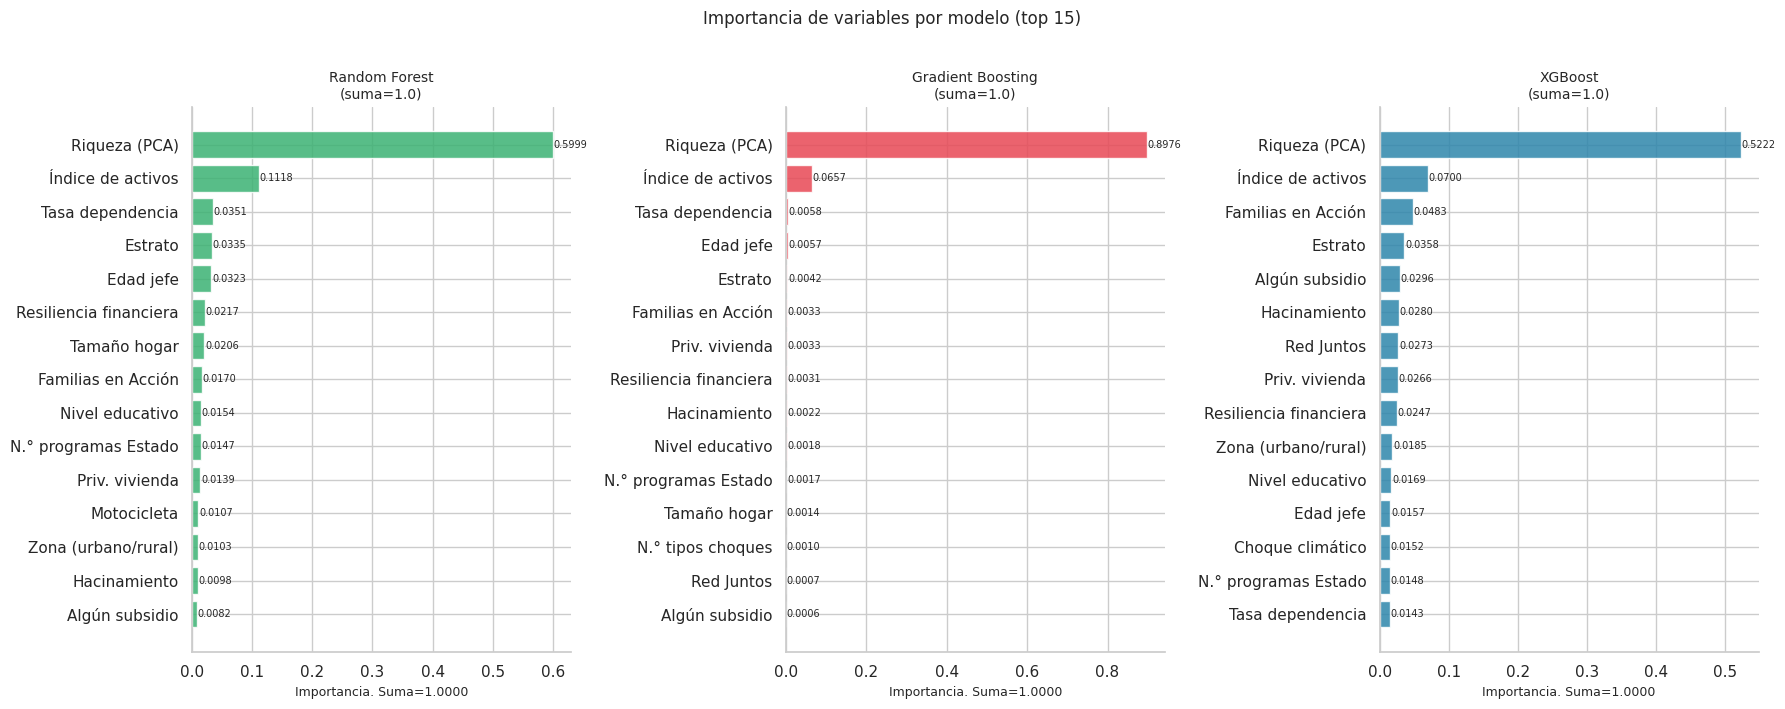

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
datos = [('Random Forest\n(suma=1.0)', imp_rf, '#3BB273'),
         ('Gradient Boosting\n(suma=1.0)', imp_gb, '#E84855'),
         ('XGBoost\n(suma=1.0)', imp_xgb, '#2E86AB')]

for ax, (titulo, imp, color) in zip(axes, datos):
    top15 = imp.sort_values(ascending=True).tail(15)
    etiq  = [nombres_leg.get(i, i) for i in top15.index]
    bars  = ax.barh(etiq, top15.values, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, top15.values):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7)
    ax.set_xlabel(f'Importancia. Suma={imp.sum():.4f}', fontsize=9)
    ax.set_title(titulo, fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Importancia de variables por modelo (top 15)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/content/outputs/importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

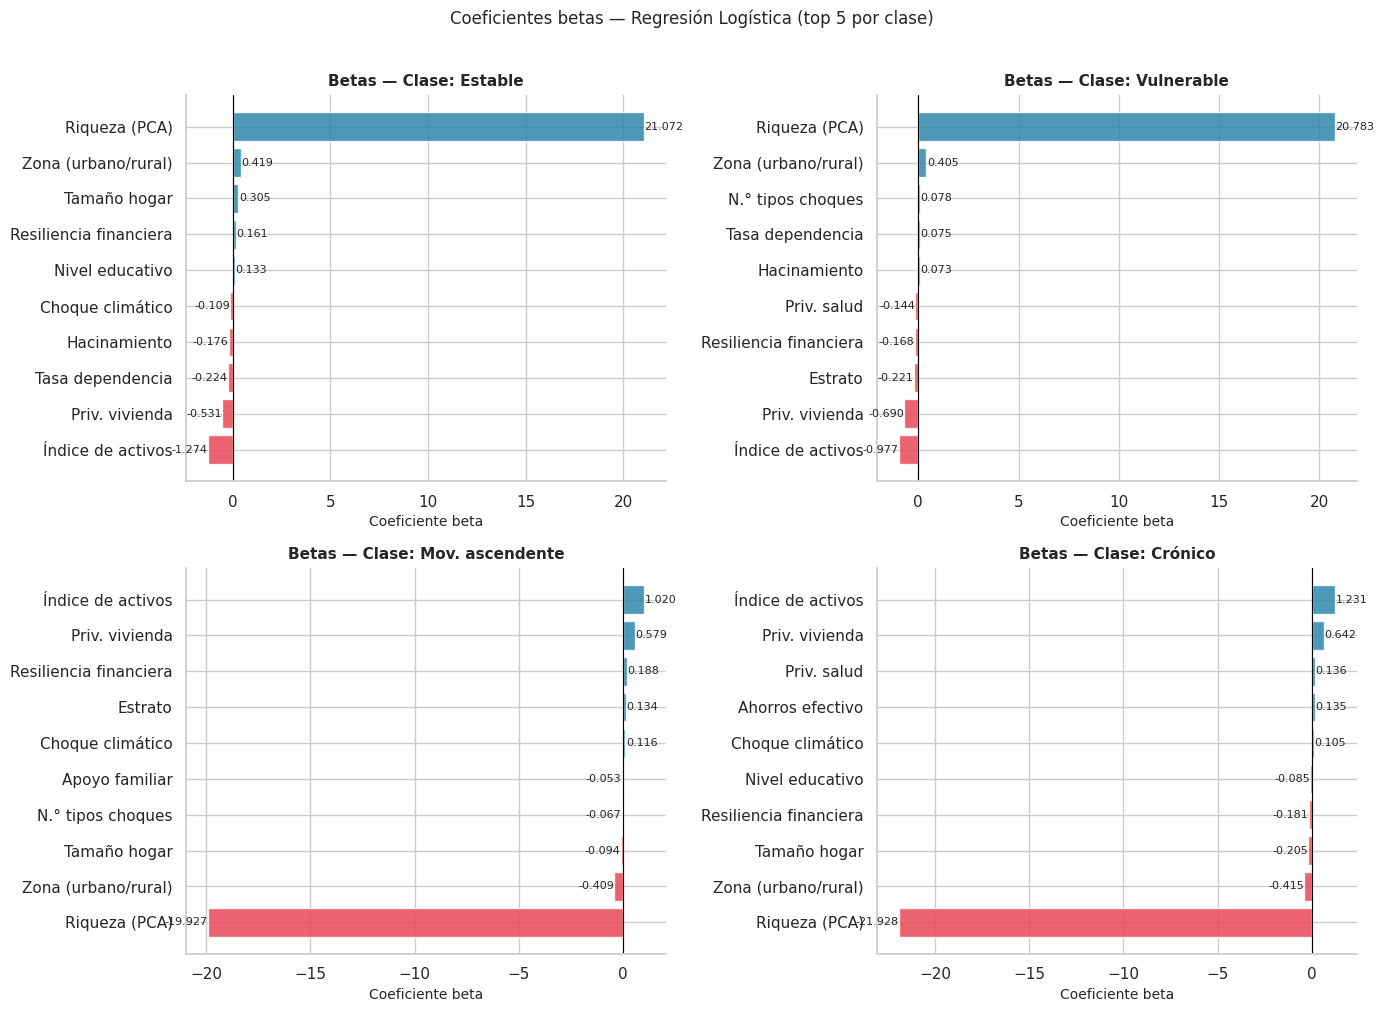

In [22]:
lr_best = grid_lr.best_estimator_
betas   = pd.DataFrame(lr_best.coef_,
                        index=[TRANS[i] for i in range(4)],
                        columns=features).T
betas.index = [nombres_leg.get(i, i) for i in betas.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, clase in enumerate(TRANS.values()):
    coefs     = betas[clase].sort_values()
    plot_data = pd.concat([coefs.head(5), coefs.tail(5)]).sort_values()
    colores_b = ['#E84855' if v < 0 else '#2E86AB' for v in plot_data.values]
    bars = axes[idx].barh(plot_data.index, plot_data.values,
                           color=colores_b, edgecolor='white', alpha=0.85)
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(f'Betas — Clase: {clase}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Coeficiente beta', fontsize=10)
    axes[idx].spines['top'].set_visible(False); axes[idx].spines['right'].set_visible(False)
    for bar, val in zip(bars, plot_data.values):
        ha = 'left' if val >= 0 else 'right'
        axes[idx].text(val+(0.02 if val>=0 else -0.02),
                       bar.get_y()+bar.get_height()/2,
                       f'{val:.3f}', va='center', ha=ha, fontsize=8)

plt.suptitle('Coeficientes betas — Regresión Logística (top 5 por clase)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/content/outputs/betas_regresion_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10b. Análisis SHAP — interpretabilidad del XGBoost

**SHAP (SHapley Additive exPlanations)** mide la contribución de cada variable a la predicción de cada hogar individual.

A diferencia de la importancia de variables (que da un promedio global), SHAP muestra:
- **Dirección:** si la variable empuja hacia o en contra de cada clase
- **Magnitud:** cuánto aporta esa variable para cada hogar específico
- **Distribución:** cómo varía el efecto entre todos los hogares

Se realiza con el **modelo campeón (XGBoost)** tal como recomienda la docente.

In [25]:
!pip install shap --quiet
import shap

print("Calculando valores SHAP para el XGBoost campeón...")

X_test_df = pd.DataFrame(X_test_proc, columns=features)
nombres_features = [nombres_leg.get(f, f) for f in features]

explainer    = shap.TreeExplainer(best_model)
shap_values  = explainer.shap_values(X_test_df)

# Manejar formato según versión de SHAP
if isinstance(shap_values, list):
    # Formato antiguo: lista de arrays (n_samples, n_features)
    print(f"Formato: lista de {len(shap_values)} clases")
    sv = shap_values
else:
    # Formato nuevo: array 3D (n_samples, n_features, n_classes)
    print(f"Formato: array 3D {shap_values.shape}")
    sv = [shap_values[:, :, i] for i in range(4)]

print("SHAP calculado correctamente")

Calculando valores SHAP para el XGBoost campeón...
Formato: array 3D (3392, 26, 4)
SHAP calculado correctamente


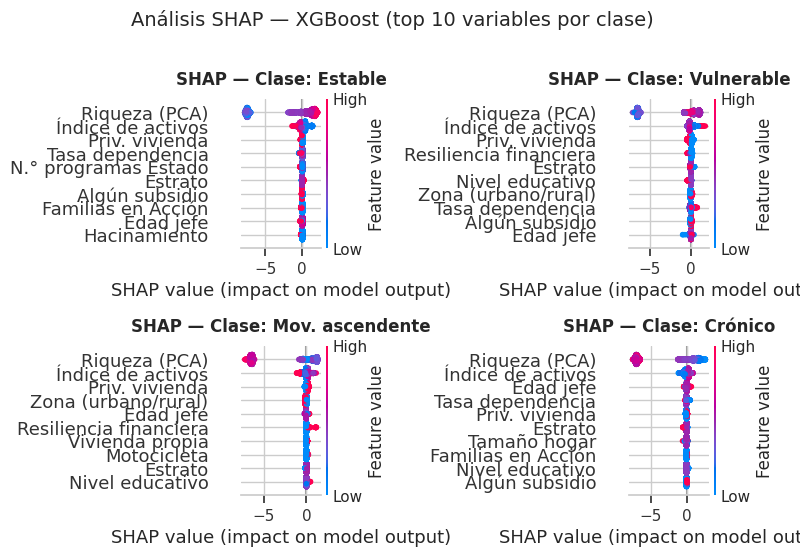

Guardada: shap_summary.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, clase in enumerate(TRANS.values()):
    plt.sca(axes[idx])
    shap.summary_plot(
        sv[idx],
        X_test_df,
        feature_names=nombres_features,
        max_display=10,
        show=False,
        plot_type='dot'
    )
    axes[idx].set_title(f'SHAP — Clase: {clase}', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Análisis SHAP — XGBoost (top 10 variables por clase)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: shap_summary.png")

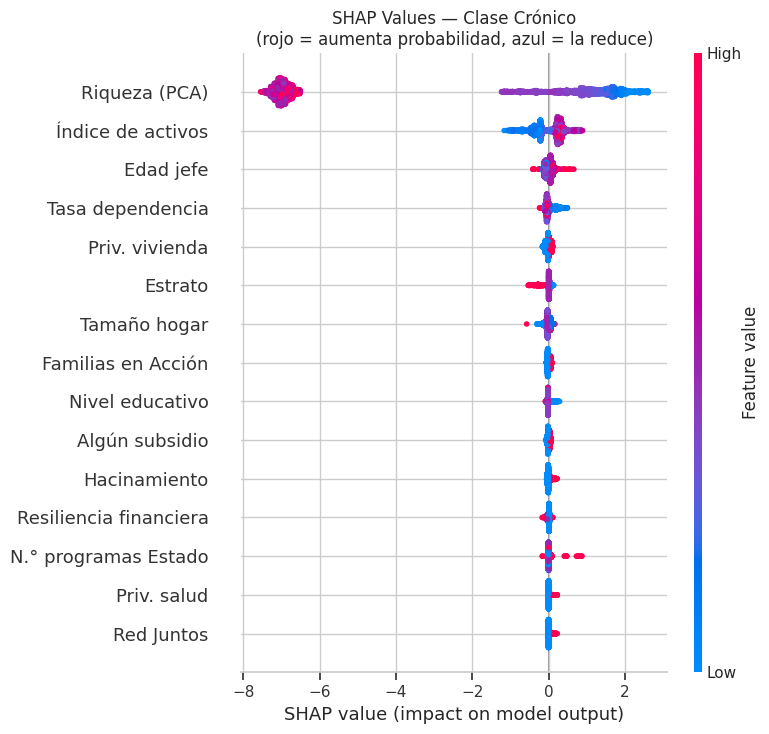

In [27]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv[3],
    X_test_df,
    feature_names=nombres_features,
    max_display=15,
    show=False
)
plt.title('SHAP Values — Clase Crónico\n(rojo = aumenta probabilidad, azul = la reduce)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/outputs/shap_cronico.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Descargar todas las gráficas

In [ ]:
from google.colab import files

graficas = [
    '/content/outputs/shap_summary.png',
    '/content/outputs/shap_cronico.png',
    '/content/outputs/comparacion_modelos_cv.png',
    '/content/outputs/ajuste_umbral.png',
    '/content/outputs/matriz_confusion_mejor_modelo.png',
    '/content/outputs/curva_roc.png',
    '/content/outputs/importancia_variables.png',
    '/content/outputs/betas_regresion_logistica.png',
]

print("Descargando graficas...")
for g in graficas:
    if os.path.exists(g):
        files.download(g)
        print(f"  OK  {g.split('/')[-1]}")
    else:
        print(f"  FALTA  {g.split('/')[-1]}")

print()
print("Nota: la matriz de confusion usa el umbral optimo (0.19)")
print("      que es la evaluacion oficial del modelo.")